In [ ]:
import pandas as pd
import importlib

from UniversoActivos import UniversoActivosEstatico, UniversoActivosDinamico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
import Modelos
Modelos = importlib.reload(Modelos)
from Estrategia import EstrategiaMLEquiponderada, EstrategiaMLMinVarAlphaTilt, EstrategiaMLMonteCarlo
from Backtest import BacktestEngine

RandomForestModel = Modelos.RandomForestModel
XGBoostModel = Modelos.XGBoostModel

# EURO STOXX 50

In [ ]:
import pandas as pd
import requests

def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    
    # Añadimos una cabecera para simular un navegador real
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }
    
    # Hacemos la petición con requests
    response = requests.get(url, headers=headers)
    
    # Pasamos el contenido HTML (response.text) a pandas
    tables = pd.read_html(response.text)
    
    # Buscamos la tabla que contiene la columna 'Ticker'
    df = next(table for table in tables if 'Ticker' in table.columns)
    
    return df['Ticker'].tolist()

tickers = get_eurostoxx50_tickers()
print(f"Total empresas: {len(tickers)}")
print(f"Muestra: {tickers}")

# tickers = [
#     "ADS.DE",    # Adidas
#     "ADYEN.AS",  # Adyen
#     "AD.AS",     # Ahold Delhaize
#     "AI.PA",     # Air Liquide
#     "AIR.PA",    # Airbus
#     "ALV.DE",    # Allianz
#     "ABI.BR",    # Anheuser-Busch InBev
#     "ASML.AS",   # ASML
#     "CS.PA",     # AXA
#     "BBVA.MC",   # BBVA
#     "SAN.MC",    # Santander
#     "BAS.DE",    # BASF
#     "BAYN.DE",   # Bayer
#     "BMW.DE",    # BMW
#     "BNP.PA",    # BNP Paribas
#     "CRH.L",     # CRH
#     "MBG.DE",    # Mercedes-Benz
#     "BN.PA",     # Danone
#     "DB1.DE",    # Deutsche Börse
#     "DHL.DE",    # Deutsche Post
#     "DTE.DE",    # Deutsche Telekom
#     "ENEL.MI",   # Enel
#     "ENI.MI",    # ENI
#     "EL.PA",     # EssilorLuxottica
#     "FLTR.L",    # Flutter Entertainment
#     "RMS.PA",    # Hermès
#     "IBE.MC",    # Iberdrola
#     "ITX.MC",    # Inditex
#     "IFX.DE",    # Infineon
#     "INGA.AS",   # ING Groep
#     "ISP.MI",    # Intesa Sanpaolo
#     "KER.PA",    # Kering
#     "KNEBV.HE",  # Kone
#     "OR.PA",     # L'Oréal
#     "LIN.DE",    # Linde
#     "MC.PA",     # LVMH
#     "MUV2.DE",   # Münchener Rück
#     "RI.PA",     # Pernod Ricard
#     "PHIA.AS",   # Philips
#     "PRX.AS",    # Prosus
#     "SAF.PA",    # Safran
#     "SAN.PA",    # Sanofi
#     "SAP.DE",    # SAP
#     "SU.PA",     # Schneider Electric
#     "SIE.DE",    # Siemens
#     "STLAM.MI",  # Stellantis (no STLA.MI)
#     "TTE.PA",    # TotalEnergies
#     "DG.PA",     # Vinci
#     "VOW3.DE",   # Volkswagen Pref
#     "VNA.DE",    # Vonovia
# ]

Total empresas: 50
Muestra: ['ADS.DE', 'ADYEN.AS', 'AD.AS', 'AI.PA', 'AIR.PA', 'ALV.DE', 'ABI.BR', 'ARGX.BR', 'ASML.AS', 'CS.PA', 'BAS.DE', 'BAYN.DE', 'BBVA.MC', 'SAN.MC', 'BMW.DE', 'BNP.PA', 'BN.PA', 'DBK.DE', 'DB1.DE', 'DHL.DE', 'DTE.DE', 'ENEL.MI', 'ENI.MI', 'EL.PA', 'RACE.MI', 'RMS.PA', 'IBE.MC', 'ITX.MC', 'IFX.DE', 'INGA.AS', 'ISP.MI', 'OR.PA', 'MC.PA', 'MBG.DE', 'MUV2.DE', 'NDA-FI.HE', 'PRX.AS', 'RHM.DE', 'SAF.PA', 'SGO.PA', 'SAN.PA', 'SAP.DE', 'SU.PA', 'SIE.DE', 'ENR.DE', 'TTE.PA', 'DG.PA', 'UCG.MI', 'VOW.DE', 'WKL.AS']


C:\Users\jpuerta\AppData\Local\Temp\ipykernel_14152\4012662861.py:16: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


## RandomForest + EstrategiaMLMonteCarlo

In [ ]:
start_date = "2023-01-03"
end_date = "2024-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=10, ticker_indice="^STOXX50E")
modelo = RandomForestModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])


1 Failed download:
['INGA.AS']: TypeError("'NoneType' object is not subscriptable")
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[Train] 2017-01-06 → 2022-12-30 | AUC=0.5076 | {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 0.01, 'n_estimators': 250}


KeyboardInterrupt: 

## Random Forest + EstrategiaMLEquiponderada

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


[Train] 2019-01-11 → 2022-12-30 | AUC=0.4997 | {'max_depth': 6, 'max_features': None, 'min_samples_leaf': 0.01, 'n_estimators': 150}
[Train] 2019-07-12 → 2023-06-30 | AUC=0.5054 | {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 0.05, 'n_estimators': 150}
[Train] 2020-01-10 → 2023-12-29 | AUC=0.4966 | {'max_depth': 3, 'max_features': 0.8, 'min_samples_leaf': 0.01, 'n_estimators': 400}


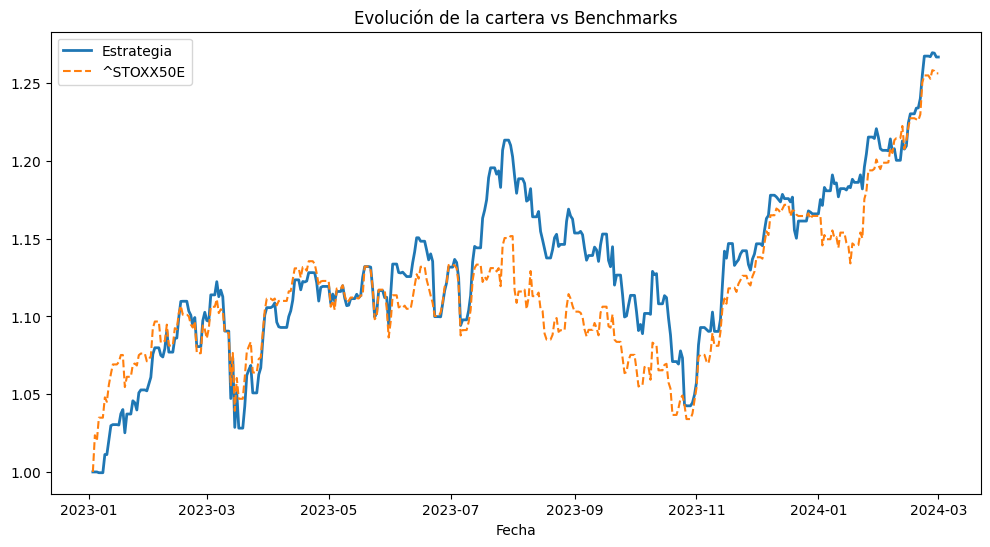

,Estrategia,^STOXX50E
Rentabilidad total,26.69%,25.64%
Rentabilidad anualizada,15.14%,14.57%
Volatilidad anualizada,12.46%,11.51%
Sharpe,1.19,1.24
Sortino,1.66,1.78
Max Drawdown,-14.08%,-10.22%
Calmar,1.07,1.43
Win rate,38.30%,38.53%
Mejor periodo,2.51%,2.36%
Peor periodo,-4.16%,-3.46%


In [ ]:
start_date = "2023-01-03"
end_date = "2024-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio="mediana", ticker_indice="^STOXX50E")
modelo = RandomForestModel(random_state=42, n_splits=3)  # ← solo random_state, el resto lo decide el CV
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=15, umbral_salida=22)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

## XGBoostModel + EstrategiaMLMonteCarlo

c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arrays\datetimes.py:668: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000276EA8A96C0>
  converted = ints_to_pydatetime(
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arrays\datetimes.py:668: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000276EBC60E50>
  converted = ints_to_pydatetime(
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arrays\datetimes.py:668: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000276EBC618A0>
  converted = ints_to_pydatetime(
c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\internals\blocks.py:826: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000276F1C5D7B0>
  return type(self)(values, placement=self._mgr_locs, ndim=self.ndim, refs=refs)
c:\Users\jpuerta\

[Train] 2019-01-11 → 2022-12-30 | AUC=0.5156 | {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 250, 'subsample': 1.0}
[Train] 2019-07-12 → 2023-06-30 | AUC=0.5065 | {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 150, 'subsample': 1.0}
[Train] 2020-01-10 → 2023-12-29 | AUC=0.5031 | {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150, 'subsample': 1.0}


c:\Users\jpuerta\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\cbook.py:266: ResourceWarning: unclosed database in <sqlite3.Connection object at 0x00000276EA8A9030>
  self._pickled_cids = set()


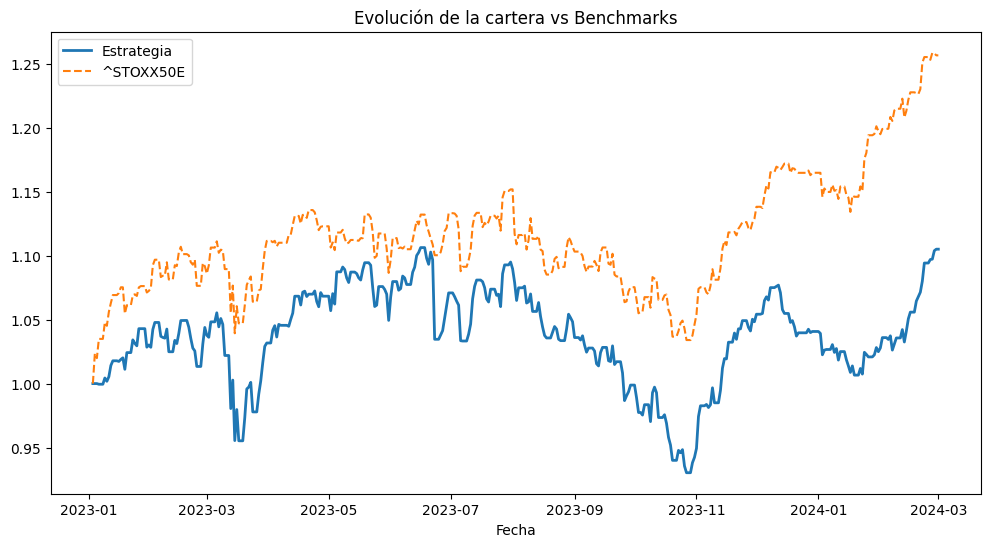

,Estrategia,^STOXX50E
Rentabilidad total,10.50%,25.64%
Rentabilidad anualizada,6.13%,14.57%
Volatilidad anualizada,13.43%,11.51%
Sharpe,0.51,1.24
Sortino,0.68,1.78
Max Drawdown,-15.90%,-10.22%
Calmar,0.39,1.43
Win rate,37.35%,38.53%
Mejor periodo,2.62%,2.36%
Peor periodo,-5.67%,-3.46%


In [ ]:
start_date = "2023-01-03"
end_date = "2024-03-01"

universo = UniversoActivosDinamico(tickers_actuales=tickers, start_date=start_date,
                                   end_date=end_date, csv_cambios_path=r"eurostoxx50_historico_cambios.csv")
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio="mediana", ticker_indice="^STOXX50E")
modelo = XGBoostModel(random_state=42, n_splits=3)
estrategia = EstrategiaMLMonteCarlo(modelo=modelo, n_activos_obj=15, umbral_salida=22,
                                    n_simulaciones=5000, peso_min=0.02)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=6,
    nominal=10000000
)

res = engine.print_results(bmks=["^STOXX50E"])

In [ ]:
import yfinance as yf
from datetime import datetime

# Selecciona el ticker que quieras, por ejemplo 'ADS.DE'
ticker = 'ONSW.DE'

# Descarga los datos de hoy
hoy = datetime.today().strftime('%Y-%m-%d')
data = yf.download(ticker)

print(data)

## XGBoostModel + EstrategiaMLMinVarAlphaTilt

In [ ]:
modelo = XGBoostModel(n_estimators=180, max_depth=3, positive_class_weight=8.0)

estrategia = EstrategiaMLMinVarAlphaTilt(
    modelo=modelo,
    n_activos_obj=10,
    umbral_salida=15,      # universo candidato para optimización
    p_neutral=0.55,        # más conservador que 0.50
    alpha_scale=1.0,
    lambda_risk=5.0,       # subir para bajar volatilidad
    lambda_tc=0.001,       # subir para rotar menos
    w_max=0.20,
    turnover_max=0.20,
    no_trade_band=0.002,   # 40 bps de banda
    coste_transaccion=0.0005,  # 5 bps
    utility_buffer=0.0001,     # histéresis adicional
    min_hist_obs=26
)
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date=start_date,
    end_date=end_date,
    len_ventana=2,
    nominal=10000000
)

res4 = engine.print_results(bmks=["^STOXX50E"])